<a href="https://colab.research.google.com/github/siddub306/Open-source-Practice/blob/main/MNIST_Digit_Classification_with_CNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Digit Classification using CNN



# Importing dependencies

In [ ]:
import numpy as np  # for algebraic and matrix manipulation
import matplotlib.pyplot as plt  # for visualising plots and graphs
import tensorflow as tf  # Tensorflow backend for Keras to run on
from tensorflow import keras  # for all deep learning model building and compiling tasks

# Loading Dataset

The MNIST dataset is one of the most common datasets used for image classification and accessible from many different sources. In fact, even Tensorflow and Keras allow us to import and download the MNIST dataset directly from their API.

In [ ]:
# Loading dataset from Keras API
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11493376/11490434 [==============================] - 0s 0us/step


### Showing the digit image along with the label

In [ ]:
x_train[:1]

array([[[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           3,  18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,
           0,   0,   0

8


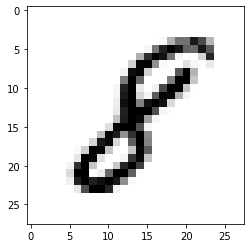

In [ ]:
image_index = 7777 # You may select anything up to 60,000
print(y_train[image_index])
plt.imshow(x_train[image_index], cmap='Greys')

In [ ]:
x_train.shape

(60000, 28, 28)

# Data Preprocessing

To be able to use the dataset in Keras API, we need 4-dims NumPy arrays. However, as we see above, our array is 3-dims. In addition, we must normalize our data as it is always required in neural network models. We can achieve this by dividing the RGB codes to 255 (which is the maximum RGB code minus the minimum RGB code)

In [ ]:
# Reshaping the array to 4-dims so that it can work with the Keras API
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

# Making sure that the values are float so that we can get decimal points after division
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# Normalizing the RGB codes by dividing it to the max RGB value.
x_train /= 255
x_test /= 255

print('x_train shape:', x_train.shape)
print('Number of images in x_train', x_train.shape[0])
print('Number of images in x_test', x_test.shape[0])

x_train shape: (60000, 28, 28, 1)
Number of images in x_train 60000
Number of images in x_test 10000


x_train shape: (60000, 28, 28, 1) denotes:

>Number of images: 60000

>Number of columns in one image matrix: 28

>Number of rows in one image matrix: 28

>Number of channels for one image: 1

# CNN Model Building

In [ ]:
# Importing the required Keras modules containing model and layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

# Creating a Sequential Model and adding the layers
model = Sequential()

model.add(Conv2D(filters=28, kernel_size=(3,3), input_shape=input_shape))
# filters: the number of output filters in the convolution
# kernel_size: specifies the height and width of the 2D convolution window
# input_shape: 4+D tensor with shape: batch_shape + (rows, cols, channels)

model.add(MaxPooling2D(pool_size=(2, 2)))
# window size over which to take the maximum.
# (2, 2) will take the max value over a 2x2 pooling window

model.add(Flatten()) # Flattening the 2D arrays to 1D array for fully connected layers

model.add(Dense(128, activation='relu'))
# units: dimensionality of the output space
# activation: Activation function to use

model.add(Dropout(0.2)) # Reduce overfitting by disregarding some of the neurons

model.add(Dense(10,activation='softmax'))
# units: dimensionality of the output space, here 10 due to our output being 10 labels from 0-9
# activation: Activation function to use

### Model Compiling and Fitting

In [ ]:
# Compile the model and fit it to the training datasets
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x=x_train,y=y_train, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.2026 - accuracy: 0.9391
Epoch 2/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0826 - accuracy: 0.9743
Epoch 3/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0570 - accuracy: 0.9817
Epoch 4/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0438 - accuracy: 0.9861
Epoch 5/10
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0335 - accuracy: 0.9893
Epoch 6/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0293 - accuracy: 0.9904
Epoch 7/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0250 - accuracy: 0.9916
Epoch 8/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0208 - accuracy: 0.9927
Epoch 9/10
1875/1875 [==============================] - 30s 16ms/step - loss: 0.0185 - accuracy: 0.9934
Epoch 10/10
1875/1875 [==============================] - 36s 19m

# Model Evaluation

In [ ]:
model.evaluate(x_test, y_test)

313/313 [==============================] - 2s 7ms/step - loss: 0.0665 - accuracy: 0.9840


[0.06647507101297379, 0.984000027179718]

5


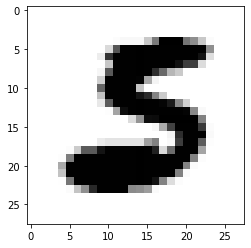

In [ ]:
image_index = 7777
plt.imshow(x_test[image_index].reshape(28, 28),cmap='Greys')
pred = model.predict(x_test[image_index].reshape(1, 28, 28, 1))
print(pred.argmax())